In [1]:
print("all okay")

all okay


In [2]:
from research_and_analysis.utils.model_loader import ModelLoader

In [3]:
model_loader = ModelLoader()

{"timestamp": "2026-09-21T04:32:51.432621Z", "level": "info", "event": "GROQ_API_KEY loaded from environment"}
{"timestamp": "2026-09-21T04:32:51.433621Z", "level": "info", "event": "COHERE_API_KEY loaded from environment"}
{"config_keys": ["astra_db", "embedding_model", "retriever", "llm"], "timestamp": "2026-09-21T04:32:51.445620Z", "level": "info", "event": "YAML config loaded"}


In [4]:
llm = model_loader.load_llm()

{"provider": "groq", "model": "openai/gpt-oss-120b", "timestamp": "2026-09-21T04:32:51.454579Z", "level": "info", "event": "Loading LLM"}


In [8]:
llm.invoke("Hi").content

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


'Hello! How can I help you today?'

In [9]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

In [10]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver

In [12]:

class Analyst(BaseModel):
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    affiliation: str = Field(description="Primary affiliation of the analyst.")
    description: str = Field(description="Description of the analyst focus, concerns, and motives.")

    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"


In [14]:
class Perspective(BaseModel):
    analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

In [15]:
class GenerateAnalystsState(TypedDict):
    topic: str
    max_analysts: int
    human_analyst_feedback: str
    analysts: List[Analyst]

In [16]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}

2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts:

{human_analyst_feedback}

3. Determine the most interesting themes based upon documents and / or feedback above.

4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [17]:
def create_analyst(state: GenerateAnalystsState):
    """
    Used to create a set of AI analyst personas based on the provided research topic, editorial feedback, and specified number of analysts. The function generates a list of analysts, each with a unique name, role, affiliation, and description.
    """
    topic = state.get('topic', '')
    max_analysts = state.get('max_analysts', 1)
    human_analyst_feedback = state.get('human_analyst_feedback', '')

    structured_llm = llm.with_structured_output(Perspective)

    system_message = analyst_instructions.format(
        topic=topic,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback
    )

    analysts_prompt = structured_llm.invoke(
        [
            SystemMessage(content=system_message),
            HumanMessage(content="Generate the set of analysts.")
        ]
    )

    return {"analysts": analysts_prompt.analysts}


In [18]:
create_analyst(
    {
        'topic' : 'health',
        'max_analysts' : 3,
        'human_analyst_feedback' : 'give the real info'
    }
)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Maya Patel', role='Public Health Policy Analyst', affiliation='World Health Organization (WHO)', description='Focuses on global health policy, disease prevention strategies, health equity, and the impact of legislation on population health. Provides evidence‑based insights into pandemic preparedness, vaccination campaigns, and health system strengthening.'),
  Analyst(name='Prof. Ethan Liu', role='Medical Technology & Innovation Analyst', affiliation='Massachusetts Institute of Technology (MIT) – Health Sciences and Technology Program', description='Specializes in emerging medical technologies such as AI diagnostics, wearable biosensors, gene editing, and telemedicine platforms. Evaluates clinical efficacy, regulatory pathways, and the socioeconomic implications of rapid tech adoption.'),
  Analyst(name='Dr. Sofia García', role='Mental Health & Wellness Analyst', affiliation='National Institute of Mental Health (NIMH)', description='Examines trends in me

In [19]:
def human_feedback(state):
    pass

In [20]:
def should_continue(state: GenerateAnalystsState):
    """
    Return the next node to execute
    """
    human_analyst_feedback = state.get('human_analyst_feedback', None)
    if human_analyst_feedback:
        return "create_analyst"

In [21]:
from IPython.display import Image, display

In [22]:
builder = StateGraph(GenerateAnalystsState)

In [23]:
builder.add_node("create_analyst", create_analyst)
builder.add_node("human_feedback", human_feedback)

In [24]:
builder.add_edge(START, "create_analyst")
builder.add_edge("create_analyst", "human_feedback")
builder.add_conditional_edges(
    "human_feedback",
    should_continue,
    ["create_analyst", END]
)

In [25]:
memory = MemorySaver()

In [26]:
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory)

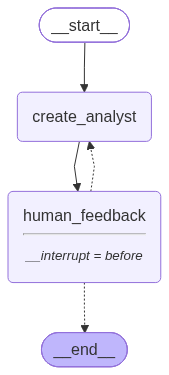

In [326]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [27]:

topic = "the benefits of adopting Langgraph as an agent framework"

In [28]:
max_analysts = 4

In [29]:
thread =  {"configurable":{"thread_id":1}}

In [30]:
for event in graph.stream({"topic":topic, "max_analysts":max_analysts}, thread, stream_mode="values"):
    analysts = event.get("analysts", '')

    if analysts:
        for anlyst in analysts:
            print(f"Name: {anlyst.name}")
            print(f"Role: {anlyst.role}")
            print(f"Affiliation: {anlyst.affiliation}")
            print(f"Description: {anlyst.description}")
            print("-" * 50)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Elena Morales
Role: Scalability and Performance Analyst
Affiliation: Institute for Distributed Systems
Description: Focuses on evaluating how Langgraph handles large-scale agent orchestration, concurrency, and latency, assessing performance benchmarks against traditional frameworks.
--------------------------------------------------
Name: Jordan Patel
Role: Developer Experience Analyst
Affiliation: OpenAI Developer Relations
Description: Examines the usability of Langgraph, including API ergonomics, documentation quality, learning curve, and its impact on developer productivity and time‑to‑market.
--------------------------------------------------
Name: Prof. Mei Lin
Role: Integration & Ecosystem Analyst
Affiliation: University of Technology, Singapore
Description: Analyzes Langgraph's compatibility with existing AI toolchains, data pipelines, and third‑party services, highlighting interoperability benefits and potential lock‑in concerns.
-------------------------------------

In [31]:
state = graph.get_state(thread)

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Analyst')]


In [32]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'analysts': [Analyst(name='Dr. Elena Morales', role='Scalability and Performance Analyst', affiliation='Institute for Distributed Systems', description='Focuses on evaluating how Langgraph handles large-scale agent orchestration, concurrency, and latency, assessing performance benchmarks against traditional frameworks.'), Analyst(name='Jordan Patel', role='Developer Experience Analyst', affiliation='OpenAI Developer Relations', description='Examines the usability of Langgraph, including API ergonomics, documentation quality, learning curve, and its impact on developer productivity and time‑to‑market.'), Analyst(name='Prof. Mei Lin', role='Integration & Ecosystem Analyst', affiliation='University of Technology, Singapore', description="Analyzes Langgraph's compatibility with existing AI toolchains, data pipelines, and third‑party services, highlighting interoperability benefits 

In [33]:
state.next

('human_feedback',)

In [34]:
graph.update_state(thread,
                   {"human_analyst_feedback":"add something from the startup perspective and focus on the latest enterprise application"},as_node="human_feedback"
                   )

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b587e-58be-6c9a-8002-477bdcb90645'}}

In [35]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')

    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

Name: Dr. Elena Morales
Affiliation: Institute for Distributed Systems
Role: Scalability and Performance Analyst
Description: Focuses on evaluating how Langgraph handles large-scale agent orchestration, concurrency, and latency, assessing performance benchmarks against traditional frameworks.
--------------------------------------------------
Name: Jordan Patel
Affiliation: OpenAI Developer Relations
Role: Developer Experience Analyst
Description: Examines the usability of Langgraph, including API ergonomics, documentation quality, learning curve, and its impact on developer productivity and time‑to‑market.
--------------------------------------------------
Name: Prof. Mei Lin
Affiliation: University of Technology, Singapore
Role: Integration & Ecosystem Analyst
Description: Analyzes Langgraph's compatibility with existing AI toolchains, data pipelines, and third‑party services, highlighting interoperability benefits and potential lock‑in concerns.
-------------------------------------

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Maya Patel
Affiliation: SeedTech Ventures
Role: Startup Innovation Analyst
Description: Focuses on how early-stage startups can leverage Langgraph for rapid prototyping, lean development, and time-to-market acceleration. Emphasizes flexibility, low overhead, and community support.
--------------------------------------------------
Name: David Liu
Affiliation: GlobalTech Solutions
Role: Enterprise Architecture Analyst
Description: Examines Langgraph's scalability, integration with existing enterprise systems, security compliance, and its fit within large-scale, mission-critical applications.
--------------------------------------------------
Name: Sofia Martinez
Affiliation: OpsInsight Consulting
Role: Operational Efficiency Analyst
Description: Analyzes cost savings, resource optimization, and workflow automation benefits of adopting Langgraph, highlighting measurable ROI and performance metrics.
--------------------------------------------------
Name: Ethan Kim
Affiliation: Futu

In [36]:
state = graph.get_state(thread)

In [37]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application', 'analysts': [Analyst(name='Maya Patel', role='Startup Innovation Analyst', affiliation='SeedTech Ventures', description='Focuses on how early-stage startups can leverage Langgraph for rapid prototyping, lean development, and time-to-market acceleration. Emphasizes flexibility, low overhead, and community support.'), Analyst(name='David Liu', role='Enterprise Architecture Analyst', affiliation='GlobalTech Solutions', description="Examines Langgraph's scalability, integration with existing enterprise systems, security compliance, and its fit within large-scale, mission-critical applications."), Analyst(name='Sofia Martinez', role='Operational Efficiency Analyst', affiliation='OpsInsight Consulting', description='Analyzes cost savings, resource optimization, and w

In [38]:
state.next

('human_feedback',)

In [39]:
further_feedack = "None"
graph.update_state(thread, {"human_analyst_feedback":further_feedack}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b587e-69ea-6d3f-8006-7d1720913edc'}}

In [40]:
final_state = graph.get_state(thread)
analysts = final_state.values.get('analysts')

## Second Workflow

In [41]:
from langchain_community.tools.tavily_search import TavilySearchResults

C:\Users\mkuma\AppData\Local\Temp\ipykernel_37244\723937994.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [42]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [43]:
tavily_api_key = "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"

In [44]:
tavily_search = TavilySearchResults(tavily_api_key=tavily_api_key)

C:\Users\mkuma\AppData\Local\Temp\ipykernel_37244\1029971610.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(tavily_api_key=tavily_api_key)


In [45]:
tavily_search.invoke("langgraph")

[{'title': 'What is LangGraph?',
  'url': 'https://www.analyticsvidhya.com/blog/2024/07/langgraph-revolutionizing-ai-agent',
  'content': 'LangGraph is a library built on top of Langchain that is designed to facilitate the creation of cyclic graphs for large language model (LLM) – based AI agents.\n It views agent Objective Points about LangGraph and workflows as cyclic graph topologies, allowing for more variable and nuanced agent behaviors than linear execution models.\n LangGraph uses key elements such as nodes (representing functions or Langchain runnable items), edges (defining execution and data flow), and stateful graphs (managing persistent data across execution cycles).\n The library supports multi-agent coordination, allowing each agent to have its prompt, LLM, tools, and custom code within a single graph structure. [...] Langgraph introduces a chat agent executor that represents the agent state as a list of messages, which is particularly useful for newer, chat-based models.

In [46]:
import operator
from typing import List, Annotated
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    max_num_turns: int
    context: Annotated[List, operator.add]
    analyst: Analyst
    interview: str
    sections: List

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval")

In [47]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic.

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.

2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}

Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.

When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [48]:
print(analyst.persona)

Name: Ethan Kim
Role: Strategic Innovation Analyst
Affiliation: FutureEdge Labs
Description: Explores how Langgraph enables new business models, AI-driven products, and competitive differentiation for both startups and enterprises through advanced agent orchestration.



In [49]:
def generate_question(state:InterviewState):
    "Node to generate the questions"

    analyst = state['analyst']
    messages = state['messages']

    system_message = question_instructions.format(goals = analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)] + messages)

    return {"messages": [question]}

In [50]:
analyst

Analyst(name='Ethan Kim', role='Strategic Innovation Analyst', affiliation='FutureEdge Labs', description='Explores how Langgraph enables new business models, AI-driven products, and competitive differentiation for both startups and enterprises through advanced agent orchestration.')

In [51]:
from langchain_core.messages import get_buffer_string

In [52]:
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert.
Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.
First, analyze the full conversation.
Pay particular attention to the final question posed by the analyst.
Convert this final question into a well-structured web search query""")

In [53]:
def search_web(state: InterviewState):
    """Node to generate web search query."""
    structured_llm = llm.with_structured_output(SearchQuery, method="json_schema")

    messages = state.get("messages", [])
    if isinstance(messages, str):
        messages = [HumanMessage(content=messages)]
    elif messages is None:
        messages = []

    response = structured_llm.invoke([search_instructions] + messages)

    query = None
    if hasattr(response, "search_query"):
        query = response.search_query
    elif isinstance(response, dict):
        query = response.get("search_query")

    # Fallback to the latest non-empty user message when structured output is empty.
    if not query:
        for msg in reversed(messages):
            content = getattr(msg, "content", None)
            if isinstance(content, str) and content.strip():
                query = content.strip()
                break

    if not query:
        query = state.get("topic", "latest updates")

    search_docs = tavily_search.invoke({"query": query})
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

In [54]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}.

You goal is to answer a question posed by the interviewer.

To answer question, use this context:

{context}

When answering questions, follow these guidelines:

1. Use only the information provided in the context.

2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1].

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc

6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list:

[1] assistant/docs/llama3_1.pdf, page 7

And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [55]:
def generate_answer(state:InterviewState):
    """Node to answer a question"""

    analyst = state['analyst']
    messages = state['messages']
    context = state['context']

    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)] + messages)

    answer.name = "expert"

    return {"messages": [answer]}

In [56]:
def route_messages(state:InterviewState, name: str = "expert"):
    """Route between question and answer"""

    messages = state['messages']
    max_num_turns = state.get('max_num_turns', 3)

    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    if num_responses >= max_num_turns:
        return 'save_interview'

    last_question = messages[-2]

    if "Thank you so much for your help!" in last_question.content:
        return 'save_interview'

    return "ask_question"

In [57]:
def save_interview(state:InterviewState):
    """Save interview"""

    messages = state['messages']

    interview = get_buffer_string(messages)

    return {"interview": interview}

In [58]:
section_writer_instructions = """You are an expert technical writer.

Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents:
- The name of each source document is at the start of the document, with the <Document tag.

2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers

3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst:
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents

6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/

8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [59]:
def write_section(state:InterviewState):
    """Node to write a section of report"""

    interview = state['interview']
    context = state['context']
    analyst = state['analyst']

    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke(
        [SystemMessage(content=system_message)]
        + [HumanMessage(content=f"Use this source to write your section: {context}")]
    )

    # `sections` is an aggregated list in ResearchGraphState, so append list entries.
    return {"sections": [section.content]}

In [60]:
interview_builder = StateGraph(InterviewState)

In [61]:
interview_builder.add_node("ask_question", generate_question)
interview_builder.add_node("search_web", search_web)
interview_builder.add_node("generate_answer", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("write_section", write_section)

In [62]:
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question", "search_web")
interview_builder.add_edge("search_web", "generate_answer")
interview_builder.add_conditional_edges("generate_answer",
                           route_messages,
                           ["ask_question",
                            "save_interview"])
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)

In [63]:
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name = "Conduct Interview")

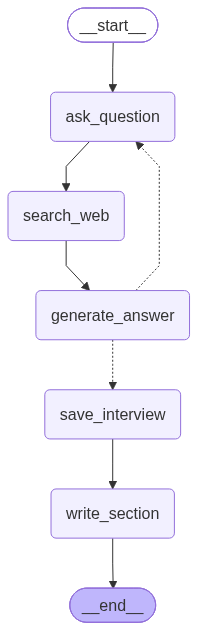

In [64]:
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [65]:
analyst

Analyst(name='Ethan Kim', role='Strategic Innovation Analyst', affiliation='FutureEdge Labs', description='Explores how Langgraph enables new business models, AI-driven products, and competitive differentiation for both startups and enterprises through advanced agent orchestration.')

In [66]:
analyst.persona

'Name: Ethan Kim\nRole: Strategic Innovation Analyst\nAffiliation: FutureEdge Labs\nDescription: Explores how Langgraph enables new business models, AI-driven products, and competitive differentiation for both startups and enterprises through advanced agent orchestration.\n'

In [67]:
thread = {"configurable": {"thread_id": "1"}}

In [68]:
from IPython.display import Markdown

In [ ]:
messages = [HumanMessage("So you said you were writing an article on Langchain?")]

In [70]:
interview = interview_graph.invoke({"analyst": analyst, "messages": messages, "max_num_turns": 2}, thread)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [371]:
interview

{'messages': [HumanMessage(content='What are the benefits of adopting Langgraph as an agent framework?', additional_kwargs={}, response_metadata={}, id='f78fdccc-790e-4569-86f6-6f4f40acba0d'),
  AIMessage(content='**Alex Morgan – Cost & Operations Analyst, FinOps Consulting Group**\n\nHi Liam, thanks for taking the time to chat. To kick things off, could you give me an overview of the **top three cost‑related benefits** you’ve observed when organizations adopt Langgraph as their agent framework? I’m especially interested in concrete examples—like how a startup’s cloud bill changed or how a large enterprise trimmed operational overhead after the switch.', additional_kwargs={'reasoning_content': 'We need to respond as an analyst interviewing the expert (Liam O\'Connor). The user asks: "What are the benefits of adopting Langgraph as an agent framework?" As the analyst, we should introduce ourselves and ask a question to the expert. Not answer directly. So we need to ask the expert about b

In [73]:
Markdown(interview['sections'][0])

## LangGraph: Powering Next‑Gen AI Business Models Through Precise Agent Orchestration  

### Summary  
The AI landscape is shifting from single‑prompt LLM calls to sophisticated, stateful agents that can reason, recover from errors, and collaborate across multiple tools. LangGraph, an open‑source orchestration framework from the LangChain team, sits at the heart of this transition. By representing agent logic as a graph of nodes and edges, it gives developers fine‑grained control over deterministic steps, LLM‑driven actions, and human‑in‑the‑loop checkpoints—all while preserving context across long‑running workflows [2][4].

What sets LangGraph apart is its visual workflow editor, which lets teams build conditional branches, loops, and back‑tracking paths without hand‑coding linear chains. Practitioners report dramatically faster debugging and clearer insight into decision points, especially for complex multi‑step reasoning tasks such as customer‑support escalations or real‑time code generation [1][4]. The built‑in state management and memory persistence ensure that agents retain context across sessions, eliminating the need for custom storage solutions [1][5].

Reliability is another differentiator. LangGraph’s durable execution checkpoints enable agents to resume exactly where they left off after a server restart or API timeout, a capability critical for enterprise‑scale deployments that may run for hours or days [4][7]. Coupled with automatic error‑recovery paths and fallback branches, production teams can prevent single‑point failures from cascading, turning “crash‑and‑burn” scenarios into manageable exceptions [1][4].

Observability and streaming further enhance user experience and operational control. Integrated tracing via LangSmith surfaces real‑time metrics, while token‑level streaming of LLM outputs, tool calls, and state updates keeps end‑users informed and reduces perceived latency [2][9]. Enterprises such as Uber, Klarna, J.P. Morgan, and AppFolio have already leveraged these features to automate unit‑test generation, power AI‑driven support bots, and accelerate property‑management decisions, reporting weekly time savings of 10+ hours and sub‑3‑minute research cycles [4][8].

The combination of deterministic orchestration, persistent state, and robust observability enables new business models: **AI‑augmented SaaS platforms** that offer customizable agent pipelines, **developer‑centric copilot tools** that iteratively refine code, and **industry‑specific autonomous agents** that blend rule‑based compliance with LLM creativity. Startups gain a rapid path to differentiated products without building low‑level infrastructure, while large enterprises achieve the control and reliability needed for mission‑critical workloads. In short, LangGraph transforms the promise of autonomous AI into a practical, production‑ready reality, delivering competitive advantage through predictable, scalable agent orchestration.  

### Sources  
[1] https://community.latenode.com/t/what-are-the-main-advantages-of-choosing-langgraph-for-ai-agent-development/31000  
[2] https://docs.langchain.com/oss/python/langgraph/overview  
[3] https://www.langchain.com/blog/deep-agents-vs-langchain-vs-langgraph  
[4] https://www.alphabold.com/langgraph-agents-in-production  
[5] https://www.ibm.com/think/topics/langgraph  
[6] https://medium.com/@saeedhajebi/langgraph-is-not-a-true-agentic-framework-3f010c780857  
[7] https://www.truefoundry.com/blog/langchain-vs-langgraph  
[8] https://www.projectpro.io/article/langgraph-projects-and-examples/1124  
[9] https://www.youtube.com/watch?v=aHCDrAbH_go  

### Third Workflow

In [74]:
from typing_extensions import TypedDict
from typing import List, Annotated
import operator
class ResearchGraphState(TypedDict):
    topic: str
    max_analysts: int
    max_num_turns: int
    human_analyst_feedback: str
    analysts: List[Analyst]
    sections: Annotated[List, operator.add]
    introduction: str
    content: str
    conclusion: str
    final_report: str

In [75]:
from langgraph.types import Send

In [76]:
def initiate_all_interviews(state:ResearchGraphState):
    """ This is the "map" step where we run each interview sub-graph using Send API """

    human_analyst_feedback = state.get('human_analyst_feedback')
    if human_analyst_feedback:
        return "create_analyst"

    else:
        topic = state.get('topic')
        return [Send("conduct_interview", {
            "analyst": analyst,
            "messages": [HumanMessage(content=f"So you said you were writing and article on {topic}?")]
        }) for analyst in state.get('analysts', [])]

In [77]:
report_writer_instructions = """You are a technical writer creating a report on this overall topic:

{topic}

You have a team of analysts. Each analyst has done two things:

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task:

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos.
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:

1. Use markdown formatting.
2. Include no pre-amble for the report.
3. Use no sub-heading.
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from:

{context}"""

In [78]:
def write_report(state: ResearchGraphState):
    """ Node to write the report """
    sections = state.get('sections', [])
    topic = state.get('topic', '')

    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])

    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)
    report = llm.invoke([SystemMessage(content=system_message)] + [HumanMessage(content="Write a report based on the above memos.")])
    return {"content": report.content}

In [79]:
intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting.

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header.

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

In [80]:
def write_introduction(state: ResearchGraphState):

    sections = state.get('sections', [])
    topic = state.get('topic', '')

    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])

    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)
    intro = llm.invoke([SystemMessage(content=instructions)] + [HumanMessage(content="Write an introduction based on the above sections.")])
    return {"introduction": intro.content}

In [81]:
def write_conclusion(state: ResearchGraphState):

    sections = state.get('sections', [])
    topic = state.get('topic', '')

    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])

    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)
    conclusion = llm.invoke([SystemMessage(content=instructions)] + [HumanMessage(content="Write a conclusion based on the above sections.")])
    return {"conclusion": conclusion.content}

In [82]:
def finalize_report(state: ResearchGraphState):
    """ Node to finalize the report """
    content = state.get('content', '')
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

In [87]:
# Add nodes and edges
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analyst)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)


In [88]:
memory = MemorySaver()

In [89]:
graph = builder.compile(interrupt_before=["human_feedback"], checkpointer=memory).with_config(run_name="Research")

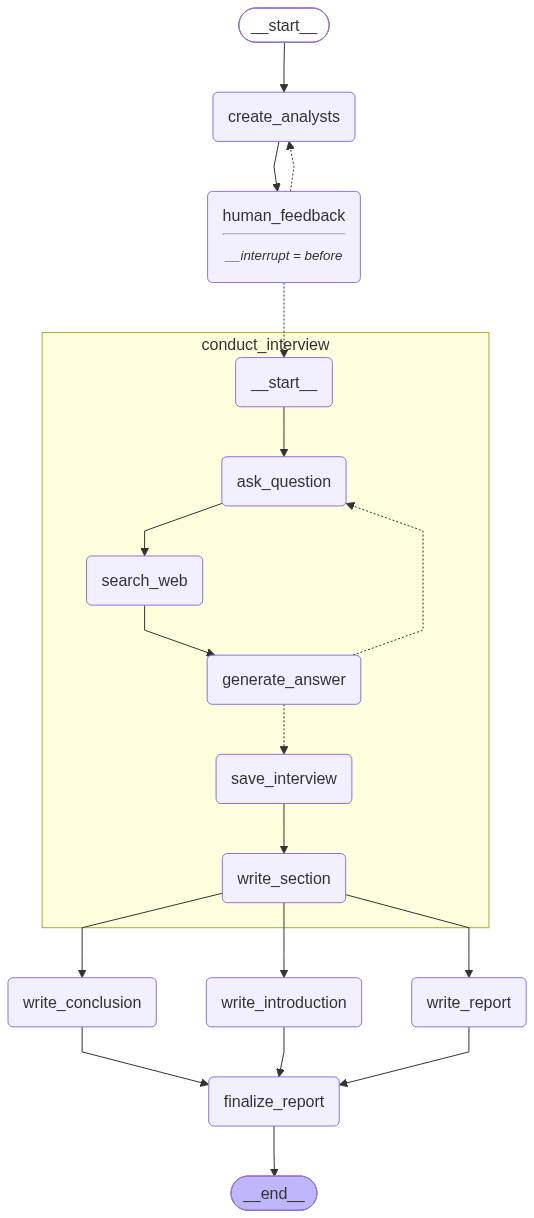

In [90]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [91]:
max_analysts = 3

In [92]:
topic = "How can generative help us to play the cricket?"

In [93]:
thread = {"configurable": {"thread_id": "2"}}

In [94]:
max_num_turns = 3

In [95]:
for event in graph.stream({'topic': topic, 'max_analysts': max_analysts, 'max_num_turns': max_num_turns}, thread, stream_mode="values"):
    analysts = event.get("analysts", '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Role: {analyst.role}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Description: {analyst.description}")
            print("-" * 50)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Aisha Patel
Role: Strategy Analyst
Affiliation: Sports Analytics Lab, University of Cambridge
Description: Specializes in applying generative AI to dissect opponent tactics, generate predictive match scenarios, and craft data-driven game plans that empower cricket teams to make smarter on‑field decisions.
--------------------------------------------------
Name: Coach Rahul Singh
Role: Skill Development Analyst
Affiliation: National Cricket Academy, India
Description: Focuses on using generative models to design personalized training modules, virtual reality simulations, and biomechanical feedback loops that accelerate batting, bowling, and fielding skill acquisition.
--------------------------------------------------
Name: Maya Liu
Role: Fan Engagement Analyst
Affiliation: MediaTech Innovations, Singapore
Description: Leverages generative AI for immersive fan experiences—automated commentary, real‑time highlight generation, virtual avatars, and interactive storytelling that b

In [96]:
graph.update_state(thread, {"human_analyst_feedback": ""}, as_node="human_feedback")

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b5898-d5dc-6319-8002-b431740d507f'}}

In [97]:
graph.get_state(thread).next

('conduct_interview', 'conduct_interview', 'conduct_interview')

In [98]:
for event in graph.stream(None, thread, stream_mode="values"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

--Node--
topic


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completion

--Node--
topic


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


--Node--
topic
--Node--
topic


In [99]:
from IPython.display import Markdown

In [100]:
final_state = graph.get_state(thread)

In [102]:
report = final_state.values.get('final_report')

In [103]:
Markdown(report)

# Generative AI: Transforming Cricket from Pitch to Broadcast  

## Introduction  

Generative AI is rewriting every facet of cricket. First, it delivers a **real‑time tactical playbook**, turning ball‑by‑ball data into instant strategy adjustments, digital twins, and win‑probability dashboards while raising governance concerns. Next, AI becomes a **creative coach**, generating personalized drills, VR opponents, biomechanical feedback, and even custom equipment, compressing feedback loops from hours to seconds. Finally, AI reshapes the **fan experience**, producing live conversational commentary, automated highlights, and hyper‑personalized storytelling that brings the sport’s rich history to new audiences. Together, these advances promise smarter on‑field decisions, accelerated skill mastery, and immersive engagement—ushering cricket into an AI‑first era.

---



Generative AI is rapidly redefining how cricket is played, trained, and experienced. By turning raw ball‑by‑ball

---

## Conclusion  

Generative AI is reshaping cricket on three fronts. First, AI‑driven tactical dashboards and digital‑twin simulations enable real‑time strategy tweaks, turning post‑match analysis into instant decision support. Second, AI‑crafted drills, biomechanical feedback, and VR avatars deliver hyper‑personalised training that compresses skill acquisition from hours to minutes. Third, AI‑powered commentary, automated highlights, and story‑telling transform fan engagement, making the sport accessible and immersive for new audiences. Together these advances unlock smarter on‑field choices, faster player development, and richer spectator experiences—while demanding robust privacy, bias‑mitigation, and human‑oversight safeguards to preserve the game’s integrity.